VAE


In [1]:
pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
batch_size = 128
latent_dim = 2  # keep 2 for visualization
epochs = 10

In [5]:
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.11MB/s]


In [6]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 400)
        self.fc3 = nn.Linear(400, 28*28)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [7]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [8]:
def loss_fn(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [9]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 784).to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_fn(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 11338047.96
Epoch 2, Loss: 10062410.46
Epoch 3, Loss: 9818618.03
Epoch 4, Loss: 9681921.23
Epoch 5, Loss: 9592952.97
Epoch 6, Loss: 9517617.81
Epoch 7, Loss: 9449733.08
Epoch 8, Loss: 9395385.63
Epoch 9, Loss: 9344493.15
Epoch 10, Loss: 9298797.43


In [10]:
model.eval()
z_list = []
labels_list = []

In [11]:
with torch.no_grad():
    for data, labels in train_loader:
        data = data.view(-1, 784).to(device)
        mu, _ = model.encode(data)
        z_list.append(mu.cpu())
        labels_list.append(labels)

In [12]:
z = torch.cat(z_list)
labels = torch.cat(labels_list)


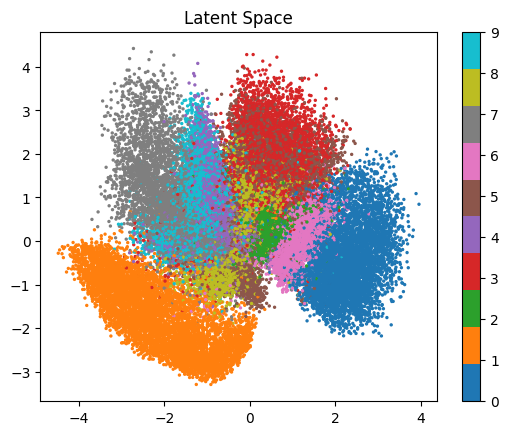

In [13]:
plt.scatter(z[:,0], z[:,1], c=labels, cmap='tab10', s=2)
plt.colorbar()
plt.title("Latent Space")
plt.show()

GAN


Epoch 1, D Loss: 0.2417, G Loss: 3.6557
Epoch 2, D Loss: 0.3944, G Loss: 2.4684
Epoch 3, D Loss: 0.5739, G Loss: 2.0188
Epoch 4, D Loss: 0.5275, G Loss: 3.0841
Epoch 5, D Loss: 0.3324, G Loss: 3.8700
Epoch 6, D Loss: 0.3070, G Loss: 2.7715
Epoch 7, D Loss: 0.4477, G Loss: 5.0218
Epoch 8, D Loss: 0.2768, G Loss: 3.7464
Epoch 9, D Loss: 0.6125, G Loss: 2.6620
Epoch 10, D Loss: 0.1998, G Loss: 3.6619


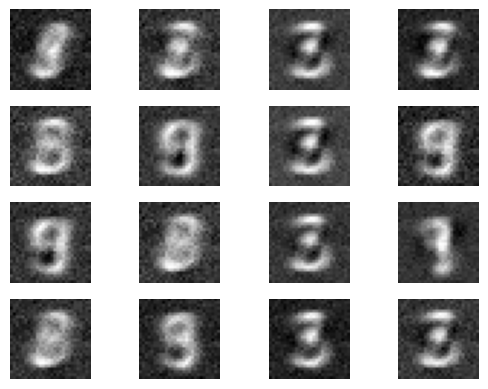

In [14]:
import torch.nn as nn

latent_dim = 100

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

# Training
for epoch in range(10):
    for real, _ in train_loader:
        real = real.view(-1, 784).to(device)

        # Labels
        real_labels = torch.ones(real.size(0), 1).to(device)
        fake_labels = torch.zeros(real.size(0), 1).to(device)

        # Train Discriminator
        z = torch.randn(real.size(0), latent_dim).to(device)
        fake = G(z)

        d_loss = loss_fn(D(real), real_labels) + \
                 loss_fn(D(fake.detach()), fake_labels)

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # Train Generator
        z = torch.randn(real.size(0), latent_dim).to(device)
        fake = G(z)
        g_loss = loss_fn(D(fake), real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

# Generate images
z = torch.randn(16, latent_dim).to(device)
generated = G(z).view(-1, 28, 28).cpu().detach()

# Plot
fig, axs = plt.subplots(4, 4)
for i, ax in enumerate(axs.flat):
    ax.imshow(generated[i], cmap='gray')
    ax.axis('off')
plt.show()

GCN

In [15]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00


In [16]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# Load dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

# GCN Model
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Testing
model.eval()
pred = model(data).argmax(dim=1)
correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())

print(f"Test Accuracy: {acc:.4f}")

Processing...
Done!


Epoch 0, Loss: 1.9509
Epoch 20, Loss: 0.1831
Epoch 40, Loss: 0.0347
Epoch 60, Loss: 0.0138
Epoch 80, Loss: 0.0112
Epoch 100, Loss: 0.0182
Epoch 120, Loss: 0.0125
Epoch 140, Loss: 0.0059
Epoch 160, Loss: 0.0039
Epoch 180, Loss: 0.0049
Test Accuracy: 0.7640
